In [ ]:
!nvidia-smi

In [2]:
# GPU Use
import os
os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"]="6"

import torch
if torch.cuda.is_available():
    device = "cuda"
    print('cuda GPU being used')
else:
    device = "cpu"
    print('WARNING! CPU being used, training will be extremely slow!')

import warnings
warnings.filterwarnings("ignore")

from glob import glob
from IPython.display import FileLink

import numpy as np
import imageio.v3 as imageio
from matplotlib import pyplot as plt

from natsort import natsort

from torch_em.util.debug import check_loader
from torch_em.data import MinInstanceSampler

import micro_sam.training as sam_training

from micro_sam.training import get_trainable_sam_model
from micro_sam.training.util import ConvertToSamInputs
from micro_sam.instance_segmentation import get_unetr
from micro_sam.training import joint_sam_trainer as joint_trainers
import torch_em

import micro_sam
print(f'MicroSAM version = {micro_sam.__version__}')

cuda GPU being used
MicroSAM version = 1.5.0


In [3]:
basedir = '../../groups/evocell/Octavio/Omnipose/'

masks = sorted(glob(f'{basedir}FM_masks/*'))
print(len(masks))

143


In [4]:
train_val_split = len(masks)*9//10

train_roi = np.s_[:train_val_split,:,:]
val_roi = np.s_[train_val_split:,:,:]

batch_size = 1
patch_shape = (512,512)
train_instance_segmentation = True

sampler = MinInstanceSampler(min_size=15, min_num_instances=5)

train_loader = sam_training.default_sam_loader(
    raw_paths = '../../groups/evocell/Octavio/Omnipose/FMRaw/Train/',
    raw_key = '*.tif',
    label_paths = '../../groups/evocell/Octavio/Omnipose/FM_masks/',
    label_key = '*.tif',    
    with_segmentation_decoder = train_instance_segmentation,
    patch_shape = patch_shape,
    batch_size = batch_size,
    is_seg_dataset = True,
    rois = train_roi,
    shuffle = True,
    raw_transform = sam_training.identity,
    sampler = sampler
    )

val_loader = sam_training.default_sam_loader(
    raw_paths = '../../groups/evocell/Octavio/Omnipose/FMRaw/Train/',
    raw_key = '*.tif',
    label_paths = '../../groups/evocell/Octavio/Omnipose/FM_masks/',
    label_key = '*.tif',
    with_segmentation_decoder = train_instance_segmentation,
    patch_shape = patch_shape,
    batch_size = batch_size,
    is_seg_dataset = True,
    rois = val_roi,
    shuffle = True,
    raw_transform = sam_training.identity,
    sampler = sampler
)

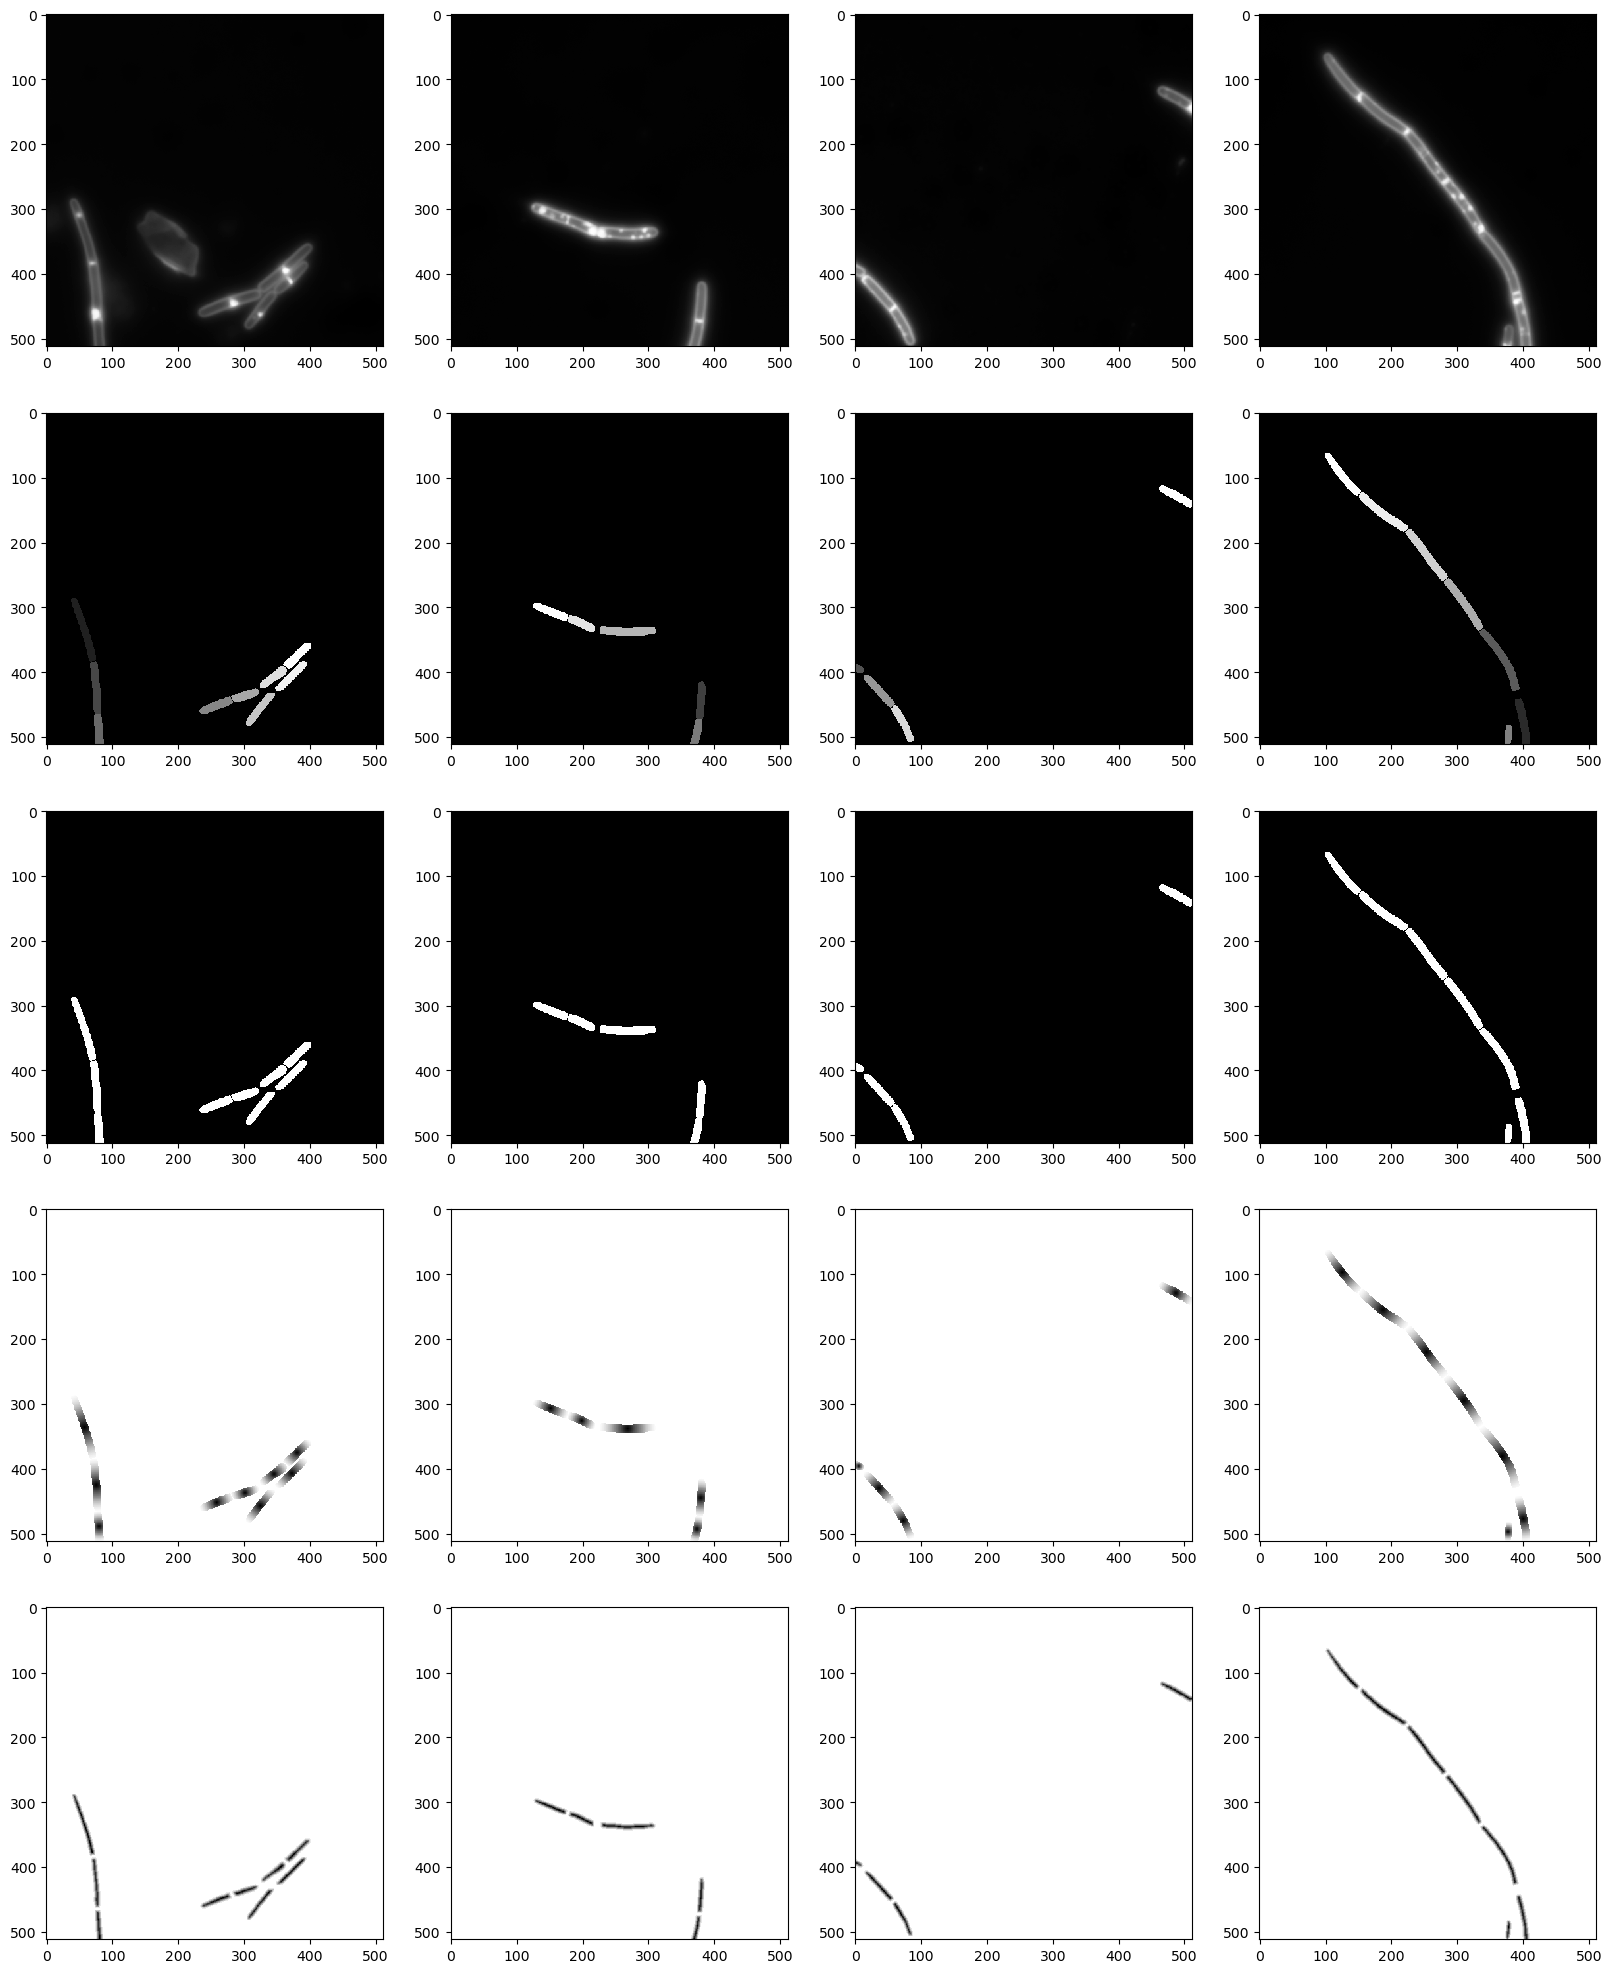

In [5]:
check_loader(train_loader,4,plt=True)

In [6]:
device = device
model_type = "vit_b_lm"
n_objects_per_batch = 1

checkpoint_name = "microSAM_FM4_raw"

# Get the trainable segment anything model.
model, state = get_trainable_sam_model(
    model_type=model_type,
    device=device,
    checkpoint_path=None,
    return_state=True,
    )

# This class creates all the training data for a batch (inputs, prompts and labels).
convert_inputs = ConvertToSamInputs(transform=model.transform, box_distortion_factor=0.025)

# Get the UNETR.
unetr = get_unetr(
    image_encoder=model.sam.image_encoder,
    decoder_state=state.get("decoder_state", None),
    device=device,
)

    # Get the parameters for SAM and the decoder from UNETR.
joint_model_params = [params for params in model.parameters()]  # sam parameters

for param_name, params in unetr.named_parameters():  # unetr's decoder parameters
    if not param_name.startswith("encoder"):
        joint_model_params.append(params)

model_params = joint_model_params
    

optimizer = torch.optim.AdamW(model_params, lr=1e-5)

scheduler_kwargs = {"mode": "min", "factor": 0.9, "patience": 3, "verbose": True}

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer=optimizer, **scheduler_kwargs)

instance_seg_loss = torch_em.loss.DiceBasedDistanceLoss(mask_distances_in_bg=True)

trainer = joint_trainers.JointSamTrainer(
        name=checkpoint_name,
        save_root='../../groups/evocell/Octavio/sam/models/',
        train_loader=train_loader,
        val_loader=val_loader,
        model=model,
        optimizer=optimizer,
        device=device,
        lr_scheduler=scheduler,
        logger=None,
        log_image_interval=100,
        mixed_precision=True,
        convert_inputs=convert_inputs,
        n_objects_per_batch=n_objects_per_batch,
        n_sub_iteration=4,
        compile_model=False,
        unetr=unetr,
        instance_loss=instance_seg_loss,
        instance_metric=instance_seg_loss,
        mask_prob=0.5,
    )
    
trainer.fit(epochs=10)

Start fitting for 17880 iterations /  10 epochs
with 1788 iterations per epoch
Training with mixed precision


Epoch 10: average [s/it]: 1.482999, current metric: 0.072659, best metric: 0.068377: 100%|████████████████████████▉| 17879/17880 [7:45:12<00:01,  1.56s/it]

Finished training after 10 epochs / 17880 iterations.
The best epoch is number 6.
